In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.shape

(1460, 81)

In [4]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [5]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


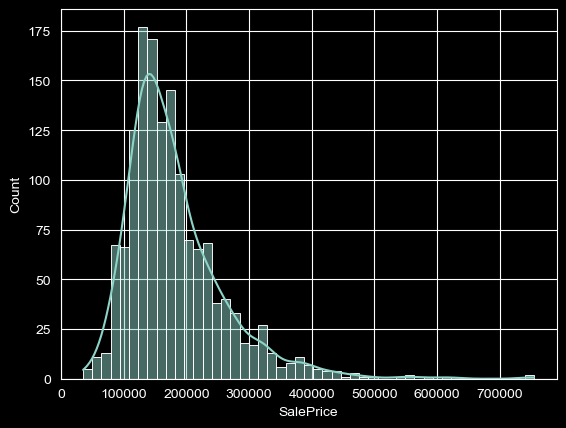

In [6]:
sns.histplot(df["SalePrice"], kde = True)
plt.show()

In [7]:
import scipy.stats as stats

In [8]:
df['Log_SalePrice'] = np.log1p(df['SalePrice'])

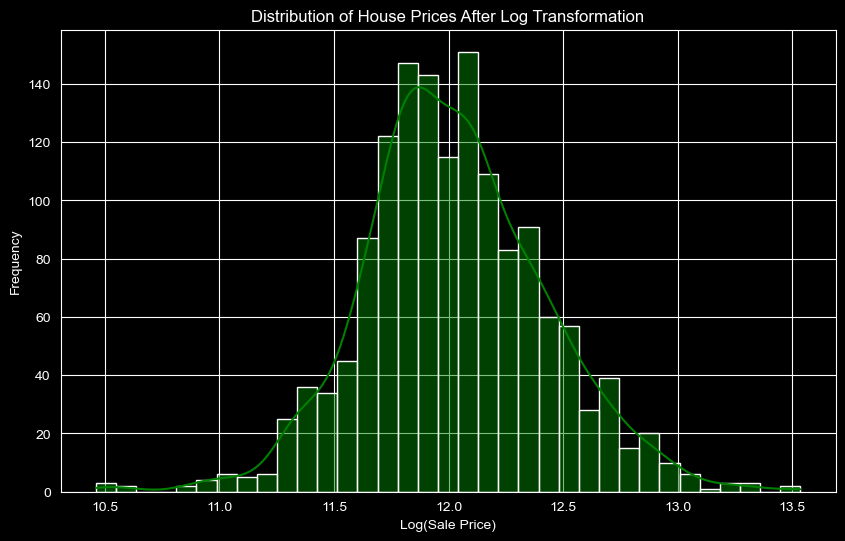

In [9]:
plt.figure(figsize = (10,6))
sns.histplot(df['Log_SalePrice'], kde = True, color = 'green')
plt.title("Distribution of House Prices After Log Transformation")
plt.xlabel("Log(Sale Price)")
plt.ylabel("Frequency")
plt.show()

In [10]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Log_SalePrice      0
Length: 82, dtype: int64

In [11]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0].sort_values(ascending = False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [12]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'MasVnrType',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']

In [13]:
for col in none_cols:
    df[col] = df[col].fillna("None")

In [14]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

In [15]:
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))

In [16]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [17]:
df.isnull().sum().sum()

np.int64(0)

In [18]:
X = df.drop(['Id', 'SalePrice', 'Log_SalePrice'], axis = 1)
y = df['Log_SalePrice']

In [19]:
X = pd.get_dummies(X, drop_first = True)

In [20]:
X.shape

(1460, 259)

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)

lr_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

print("R2 Score :", r2_score(y_test, lr_preds))
print("RMSE     :", root_mean_squared_error(y_test, lr_preds))
print("MAE      :", mean_absolute_error(y_test, lr_preds))

print("R2 Score :", r2_score(y_test, xgb_preds))
print("RMSE     :", root_mean_squared_error(y_test, xgb_preds))
print("MAE      :", mean_absolute_error(y_test, xgb_preds))

R2 Score : 0.8378839287569436
RMSE     : 0.17393286153236415
MAE      : 0.09620941113990772
R2 Score : 0.8953380832716702
RMSE     : 0.13975358223779624
MAE      : 0.0941135179098782


In [27]:
import joblib

In [28]:
joblib.dump(xgb_model, 'xgbboost_model.pkl')

['xgbboost_model.pkl']

In [29]:
model_columns = list(X.columns)
joblib.dump(model_columns, 'model_columns.pkl')

['model_columns.pkl']

In [30]:
print("Model ve kolonlar başarıyla .pkl olarak kaydedildi!")

Model ve kolonlar başarıyla .pkl olarak kaydedildi!


In [32]:
import os
import joblib

# Masaüstündeki tam proje klasörümüzün yolu
target_dir = r"C:\Users\furkan\Desktop\HousePricePrediction"

# Modelimizi ve kolonlarımızı DOĞRUDAN bu klasörün içine kaydediyoruz
joblib.dump(xgb_model, os.path.join(target_dir, "xgboost_model.pkl"))
joblib.dump(list(X.columns), os.path.join(target_dir, "model_columns.pkl"))

print("İŞLEM BAŞARILI: İki dosya da fiziksel olarak klasöre sıfırdan yazıldı!")

İŞLEM BAŞARILI: İki dosya da fiziksel olarak klasöre sıfırdan yazıldı!


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import joblib

df = pd.read_csv("train.csv")

secilen_kolonlar = ['GrLivArea', 'TotRmsAbvGrd', 'YearBuilt', 'LotFrontage', 'OverallQual', 'Neighborhood', 'SalePrice']
df = df[secilen_kolonlar].copy()

df['LotFrontage'] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))

df['Log_SalePrice'] = np.log1p(df['SalePrice'])

X = df.drop(['SalePrice', 'Log_SalePrice'], axis=1)
y = df['Log_SalePrice']

X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

model_columns = list(X.columns)
joblib.dump(xgb_model, 'xgboost_model.pkl')
joblib.dump(model_columns, 'model_columns.pkl')

print("Yeni hafifletilmiş model ve kolonlar başarıyla kaydedildi!")

Yeni hafifletilmiş model ve kolonlar başarıyla kaydedildi!
